#  Facial Expression Recognition Project (FER)

## Introduction:

#### Humans are one of the unique creatures in the world that can express and show their emotions through their faces. this project is aim to predict the emotions and recognize the expression of the face. 

## Dataset:

#### In this project we used [FER-2013 dataset](http://https://www.kaggle.com/datasets/msambare/fer2013). The FER-2013 dataset is a popular benchmark dataset used in the field of facial expression recognition. It is widely utilized for training and evaluating facial expression recognition models.

#### The dataset consists of 35,887 grayscale images, each sized 48x48 pixels. These images represent facial expressions categorized into seven emotion classes: **anger**, **disgust**, **fear**, **happiness**, **sadness**, **surprise**, and **neutral**.

In [1]:
import cv2
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,BatchNormalization
from tensorflow.keras.layers import GlobalAvgPool2D, Dense
from keras.preprocessing import image

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import cv2

def check_image_shape(image_path):
    # Load the image using OpenCV
    image = cv2.imread(image_path)

    # Check if the image is loaded successfully
    if image is None:
        print("Error: Unable to load the image.")
        return

    # Get the shape of the image
    height, width, channels = image.shape

    print("Image shape:", height, "x", width, "x", channels)

# Example usage
image_path = "/kaggle/input/fer2013/train/fear/Training_10018621.jpg"
check_image_shape(image_path)


Image shape: 48 x 48 x 3


# 1- PreProcessing:

 ##  Creating Dataframe
#### Firstly, we created the function **create_dataframe()**  to go through the folders (train, test) and retrieve the images of type 'jpg' inside each class of the expressions and store it in a dataframe, each image with its label respectively.

In [3]:
def create_dataframe(data_path):
    df = []
    for c in os.listdir(data_path):
        class_folder = os.path.join(data_path, c)
        for f in os.listdir(class_folder):
            f_path = os.path.join(class_folder, f)
            if f_path.endswith('jpg'):
                df.append([f_path, c])
    return pd.DataFrame(df, columns=('filename', 'class'))

In [4]:
# constants to be used in creating dataframes
IMG_DIM = 48 #image dimensions
DATA_PATH = '/kaggle/input/fer2013'
CLASSES = sorted(['angry', 'disgust', 'fear','happy','sad','surprise','neutral'])
print(CLASSES)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [5]:
# creating dataframes
df = create_dataframe(os.path.join(DATA_PATH, 'train'))
df_test = create_dataframe(os.path.join(DATA_PATH, 'test'))

In [6]:
# splitting the training dataframe into train and val
df_train, df_val = train_test_split(df, test_size=0.30, random_state=0)

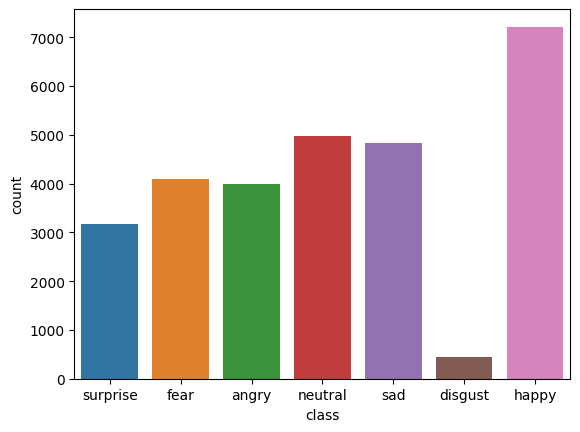

In [7]:
# plotting the number of images of each class in the data
sns.countplot(x = df["class"])
plt.xticks(rotation = 0);

### Displaying some images from the data

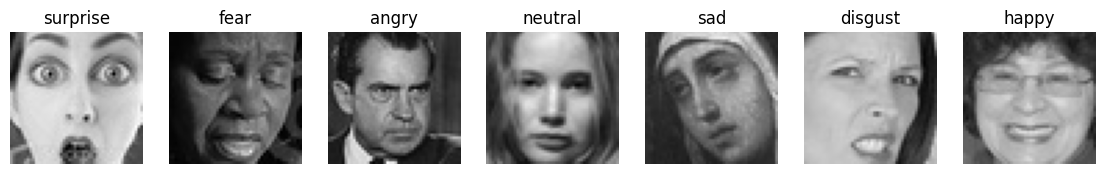

In [8]:
train_dir = '/kaggle/input/fer2013/train/'
plt.figure(figsize=(14,22))
i = 1
for expression in os.listdir(train_dir):
    img = load_img((train_dir + expression +'/'+ os.listdir(train_dir + expression)[1]))
    plt.subplot(1,7,i)
    plt.imshow(img)
    plt.title(expression)
    plt.axis('off')
    i += 1
plt.show()

### Here we dropped the class 'digust' due to its small number of images compared to the rest of the classes

In [9]:
#drop any row that have labeled as disgust in each dataframe
df = df.drop(df[df['class'] == 'disgust'].index)
df_train = df_train.drop(df_train[df_train['class'] == 'disgust'].index)
df_val = df_val.drop(df_val[df_val['class'] == 'disgust'].index)
df_test = df_test.drop(df_test[df_test['class'] == 'disgust'].index)

In [10]:
# modify CLASSES after dropping 'disgust' class.
CLASSES = sorted(['angry', 'fear','happy','sad','surprise','neutral'])

In [11]:
df_train

,filename,class
18619,/kaggle/input/fer2013/train/sad/Training_51183...,sad
11117,/kaggle/input/fer2013/train/angry/Training_106...,angry
23812,/kaggle/input/fer2013/train/happy/Training_622...,happy
12749,/kaggle/input/fer2013/train/neutral/Training_4...,neutral
11312,/kaggle/input/fer2013/train/neutral/Training_3...,neutral
...,...,...
13123,/kaggle/input/fer2013/train/neutral/Training_6...,neutral
19648,/kaggle/input/fer2013/train/sad/Training_89859...,sad
9845,/kaggle/input/fer2013/train/angry/Training_910...,angry
10799,/kaggle/input/fer2013/train/angry/Training_430...,angry


In [12]:
df_test

,filename,class
0,/kaggle/input/fer2013/test/surprise/PublicTest...,surprise
1,/kaggle/input/fer2013/test/surprise/PrivateTes...,surprise
2,/kaggle/input/fer2013/test/surprise/PrivateTes...,surprise
3,/kaggle/input/fer2013/test/surprise/PublicTest...,surprise
4,/kaggle/input/fer2013/test/surprise/PrivateTes...,surprise
...,...,...
7173,/kaggle/input/fer2013/test/happy/PublicTest_13...,happy
7174,/kaggle/input/fer2013/test/happy/PublicTest_70...,happy
7175,/kaggle/input/fer2013/test/happy/PublicTest_24...,happy
7176,/kaggle/input/fer2013/test/happy/PrivateTest_7...,happy


# 2- Augumentation
#### Here we tried to apply augumentations on the images by applying some width and height shifting, rotation, rescaling, and horizontal flipping to add some robustness and generalization to help preventing overfitting.

In [13]:
train_gen = ImageDataGenerator().flow_from_dataframe(
    df_train,
    target_size=(IMG_DIM, IMG_DIM),
    classes=CLASSES,
    color_mode='grayscale', # convert the image into grayscale
    width_shift_range = 0.1, # width shifting by range 0.1
    height_shift_range = 0.1, # height shifting by range 0.1
    rotation_range=0.1, #rotation by range 0.1
    horizontal_flip = True, # flip horizontally 
    rescale = 1./255 # rascaling the image 
)

val_gen = ImageDataGenerator().flow_from_dataframe(
    df_val,
    target_size=(IMG_DIM, IMG_DIM),
    classes=CLASSES,
    color_mode='grayscale',
    rescale = 1./255,
    shuffle=False, # turning off the shuffling
)

test_gen = ImageDataGenerator().flow_from_dataframe(
    df_test,
    target_size=(IMG_DIM, IMG_DIM),
    classes=CLASSES,
    color_mode='grayscale',
    rescale = 1./255,
    shuffle=False,
)

Found 19807 validated image filenames belonging to 6 classes.
Found 8466 validated image filenames belonging to 6 classes.
Found 7067 validated image filenames belonging to 6 classes.


In [14]:
train_gen.class_indices

{'angry': 0, 'fear': 1, 'happy': 2, 'neutral': 3, 'sad': 4, 'surprise': 5}

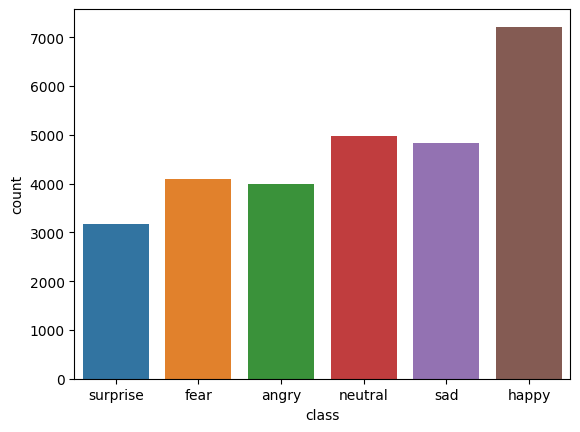

In [15]:
# plotting the number of images of each class in the data
sns.countplot(x = df["class"])
plt.xticks(rotation = 0);

In [16]:
img = train_gen[0][0][1]
img.shape

(48, 48, 1)

# 3- Building the model
#### **Convolutional Layers:** These are the building blocks of **CNNs** that learn features from input images.
#### Four sets of convolutional layers are added. Each layer extracts features using convolutional filters. The parameters include filter size **(3x3)**, number of filters **(32, 64, 64, and 128 respectively)**, activation function **(ReLU)**, and padding to maintain spatial dimensions (**'same'** padding).
#### **Max Pooling Layers:** Following each set of convolutional layers, max-pooling layers downsample the features extracted by the convolutional layers, reducing computational complexity and spatial dimensions. Max-pooling layers with a pool size of **(2, 2)** are added after each convolutional layer set.

#### **Batch Normalization:** Batch normalization layers are included after each max-pooling layer to normalize the activations of the previous layer, aiding in faster convergence and better generalization.

#### **Flattening:** The output from the convolutional layers is flattened into a single vector to be fed into the fully connected layers.
 
#### **Dense Layers:** Fully connected (Dense) layers are added for classification. Two dense layers are included with 128 units each, followed by an output layer with 6 units and a **softmax** activation function to obtain class probabilities.

#### **Model Compilation:** The model is compiled using the **'adam'** optimizer and **'categorical_crossentropy'** loss function for training. Metrics for evaluation are set to **'accuracy'**.


In [17]:
# Initialize the CNN model
model = Sequential()

# Add Convolutional layers
model.add(Conv2D(32, (3, 3),padding='same', input_shape=(IMG_DIM, IMG_DIM, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3),padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3),padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3),padding='same', activation='relu',name='last_conv'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())

# Flatten the output before feeding into the fully connected layers
model.add(Flatten())

# Add Dense layers for classification
model.add(Dense(128, activation='relu'))
model.add(Dense(6, activation='softmax'))  # Output layer with 6 units for 6 classes and softmax activation for multi-class classification

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

#MODEL_PATH = 'saved-models/cnn'

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 24, 24, 32)        0         
 D)                                                              
                                                                 
 batch_normalization (Batch  (None, 24, 24, 32)        128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 12, 12, 64)        0         
 g2D)                                                            
                                                        

### train the model

In [18]:
#training session

from tensorflow.keras.callbacks import ModelCheckpoint
# make a check point that saves the best epoch
checkpoint_path = '/kaggle/working/my_cnn_model.h5'

checkpoint = ModelCheckpoint(checkpoint_path,
                            save_weights_only=True,
                            save_best_only=True,
                            verbose=1,
                            mode='min')
# train the model in 10 epochs
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[checkpoint],
    shuffle=True
)

Epoch 1/20
619/619 [==============================] - ETA: 0s - loss: 1.5381 - accuracy: 0.3874
Epoch 1: val_loss improved from inf to 1.48596, saving model to /kaggle/working/my_cnn_model.h5
619/619 [==============================] - 154s 236ms/step - loss: 1.5381 - accuracy: 0.3874 - val_loss: 1.4860 - val_accuracy: 0.4152
Epoch 2/20
618/619 [============================>.] - ETA: 0s - loss: 1.2450 - accuracy: 0.5118
Epoch 2: val_loss improved from 1.48596 to 1.38160, saving model to /kaggle/working/my_cnn_model.h5
619/619 [==============================] - 41s 67ms/step - loss: 1.2446 - accuracy: 0.5120 - val_loss: 1.3816 - val_accuracy: 0.4613
Epoch 3/20
619/619 [==============================] - ETA: 0s - loss: 1.0967 - accuracy: 0.5794
Epoch 3: val_loss improved from 1.38160 to 1.20667, saving model to /kaggle/working/my_cnn_model.h5
619/619 [==============================] - 41s 67ms/step - loss: 1.0967 - accuracy: 0.5794 - val_loss: 1.2067 - val_accuracy: 0.5373
Epoch 4/20
619/

In [19]:
# Save the model in HDF5 format
model.save('/kaggle/working/my_cnn_model.h5')

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


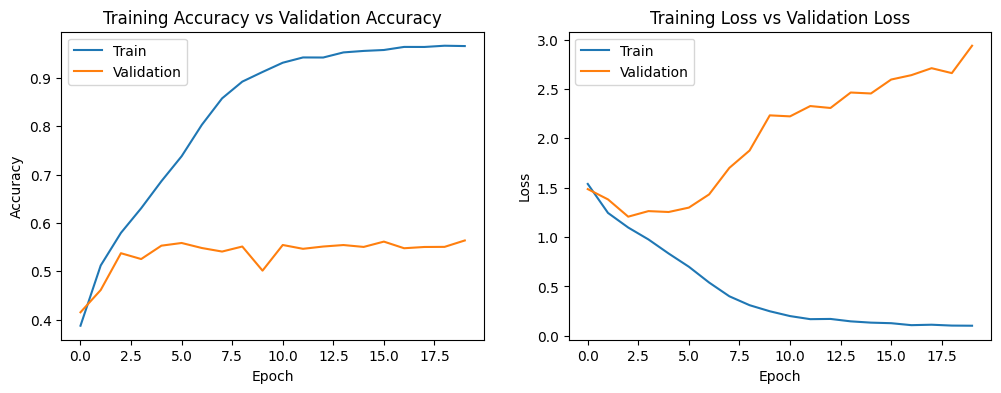

In [20]:
# plot the graphs that shows the progress of the training of each epoch and compare the training accuracy with the validation accuracy

fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
fig.set_size_inches(12,4)

ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Training Accuracy vs Validation Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(['Train', 'Validation'], loc='upper left')

ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Training Loss vs Validation Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(['Train', 'Validation'], loc='upper left')

plt.show()

### Evaluate the model

In [21]:
# evaluate the model on the testing images
print(checkpoint_path)
model.load_weights(checkpoint_path)
model.evaluate(test_gen)

/kaggle/working/my_cnn_model.h5
221/221 [==============================] - 37s 169ms/step - loss: 2.8703 - accuracy: 0.5582


[2.870314359664917, 0.5582283735275269]

# 4- Testing model

#### After training and evaluating the model, we will try to test it to see if it can predict correctly


1/1 [==============================] - 0s 321ms/step
angry


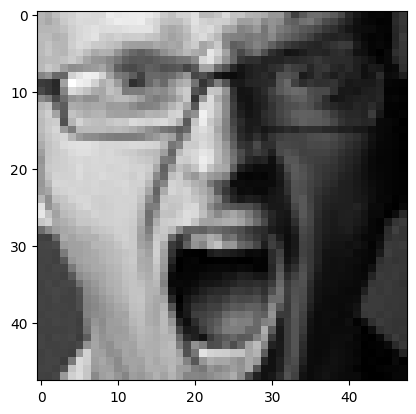

In [22]:
image = cv2.imread('/kaggle/input/fer2013/test/angry/PrivateTest_13278552.jpg',cv2.IMREAD_GRAYSCALE)
image = cv2.resize(image,(48,48),interpolation=cv2.INTER_LINEAR)
img=np.array(image)
img=img.reshape(1,48,48,1)
predict_x=model.predict(img) 
result=np.argmax(predict_x)
print(CLASSES[result])
plt.imshow(image,cmap='gray')
plt.show()


221/221 [==============================] - 11s 49ms/step
Confusion Matrix
[[ 456   86  101  117  173   25]
 [ 143  362   83  130  243   63]
 [  87   53 1394   97  113   30]
 [ 118   98  136  594  276   11]
 [ 166  132  117  222  588   22]
 [  33  100   56   47   44  551]]
Classification Report
              precision    recall  f1-score   support

       angry       0.45      0.48      0.47       958
        fear       0.44      0.35      0.39      1024
       happy       0.74      0.79      0.76      1774
     neutral       0.49      0.48      0.49      1233
         sad       0.41      0.47      0.44      1247
    surprise       0.78      0.66      0.72       831

    accuracy                           0.56      7067
   macro avg       0.55      0.54      0.54      7067
weighted avg       0.56      0.56      0.56      7067



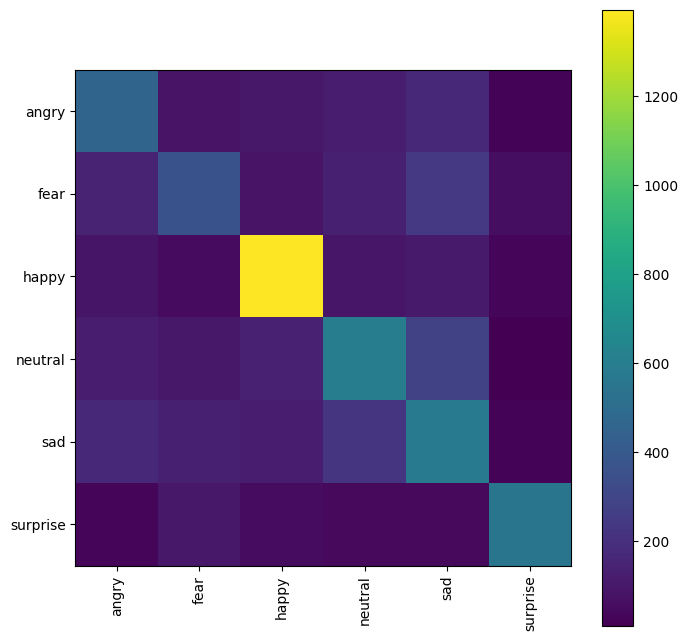

In [23]:
y_pred = model.predict(test_gen)
y_pred = np.argmax(y_pred, axis=1)
class_labels = test_gen.class_indices
class_labels = {v:k for k,v in class_labels.items()}

from sklearn.metrics import classification_report, confusion_matrix
cm_test = confusion_matrix(test_gen.classes, y_pred)
print('Confusion Matrix')
print(cm_test)
print('Classification Report')
target_names = list(class_labels.values())
print(classification_report(test_gen.classes, y_pred, target_names=target_names))

plt.figure(figsize=(8,8))
plt.imshow(cm_test, interpolation='nearest')
plt.colorbar()
tick_mark = np.arange(len(target_names))
_ = plt.xticks(tick_mark, target_names, rotation=90)
_ = plt.yticks(tick_mark, target_names)

In [24]:
pip install tf-explain


  Obtaining dependency information for tf-explain from https://files.pythonhosted.org/packages/43/75/4611078380c5f5933b71378be6733e43f10667b4ca15de6e09e12a2d8025/tf_explain-0.3.1-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 689.5 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


### Gradient-weighted Class Activation Mapping (Grad-CAM)

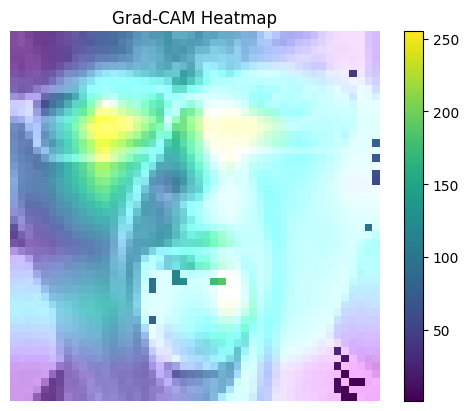

In [25]:
import numpy as np
import tensorflow as tf
from tf_explain.core.grad_cam import GradCAM
import matplotlib.pyplot as plt

# Assuming you already loaded your model and defined preprocess_image function as in your code

# Your code to obtain the Grad-CAM explanation
model = tf.keras.models.load_model('/kaggle/working/my_cnn_model.h5')

def preprocess_image(image_path):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(48, 48), color_mode="grayscale")
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    return np.expand_dims(img_array, axis=0)

image_path = '/kaggle/input/fer2013/test/angry/PrivateTest_13278552.jpg'
image = preprocess_image(image_path)
explainer = GradCAM()
grid = explainer.explain((image, None), model, class_index=0, layer_name='last_conv')

# Plot the heatmap
plt.imshow(grid, cmap='viridis')  # Choose the appropriate colormap
plt.colorbar()  # Add a colorbar to indicate values
plt.title('Grad-CAM Heatmap')
plt.axis('off')  # Hide axis
plt.show()
